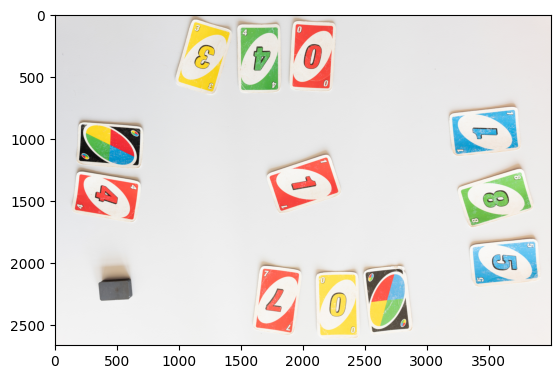

In [338]:
from importlib import reload
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import card_detection_helpers as helpers
reload(helpers)
from card_detection_helpers import *
BASE_DIR = Path.cwd().parent
TRAIN_DIR = BASE_DIR / "iapr-26-uno-vision-challenge" / "train_images"

image_paths = sorted(TRAIN_DIR.glob("*.jpg"))

'''for i in range(30):
    img_color = Image.open(image_paths[i]).convert("RGB")
    print(i)
    masks, edges = white_frames_segmentation_pipeline(img_color)
    show_cards_on_frame(img_color, edges)
    plt.show()'''

img_color = Image.open(image_paths[5]).convert("RGB")
plt.imshow(img_color)

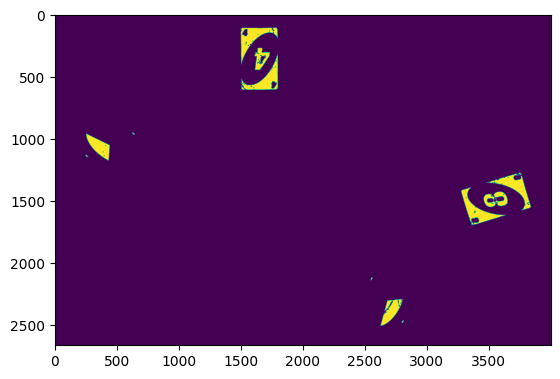

In [339]:
lower_hsv_green = np.array([40, 41, 120])
upper_hsv_green = np.array([76, 255, 255])
_ , green = helpers.mask(lower_hsv_green, upper_hsv_green,img_color,n_masks=1,space="hsv")
green=helpers.erode(5, 1, green.astype(np.uint8) * 255)
plt.imshow(green)

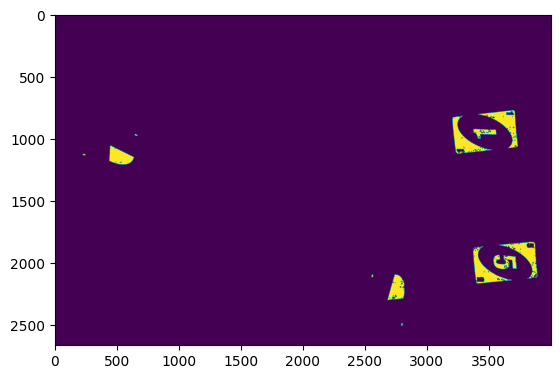

In [340]:
lower_hsv_blue = np.array([69, 41, 171])
upper_hsv_blue = np.array([127, 255, 255])

_ , blue = helpers.mask(lower_hsv_blue, upper_hsv_blue,img_color,n_masks=1,space="hsv")
blue=helpers.erode(5, 1, blue.astype(np.uint8) * 255)
plt.imshow(blue)

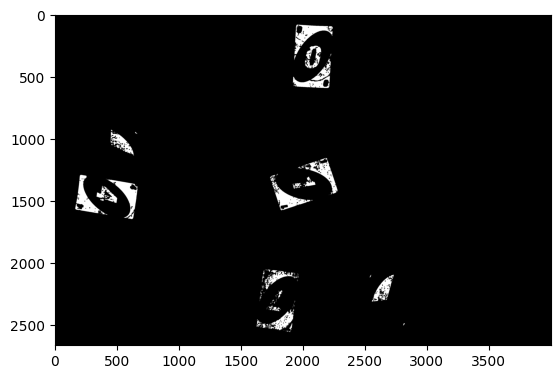

In [346]:
lower_hsv_red_1 = np.array([0, 160, 187])
upper_hsv_red_1 = np.array([4, 219, 255])
lower_hsv_red_2 = np.array([178, 160, 187])
upper_hsv_red_2 = np.array([179, 219, 255])

_ , red = helpers.mask(lower_hsv_red_1, upper_hsv_red_1,img_color,lower_hsv_red_2,upper_hsv_red_2,n_masks=2,space="hsv")
red=helpers.erode(5, 1, red.astype(np.uint8) * 255)
plt.imshow(red,cmap="gray")

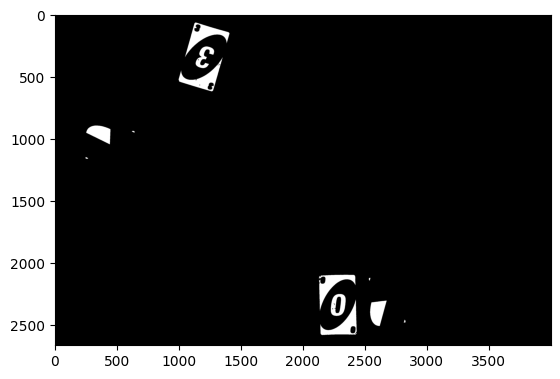

In [347]:
lower_hsv = np.array([19, 41, 226])
upper_hsv = np.array([30, 255, 255])
_ , yellow = helpers.mask(lower_hsv, upper_hsv,img_color,n_masks=1,space="hsv")
yellow=helpers.erode(5, 1, yellow.astype(np.uint8) * 255)
plt.imshow(yellow,cmap="gray")

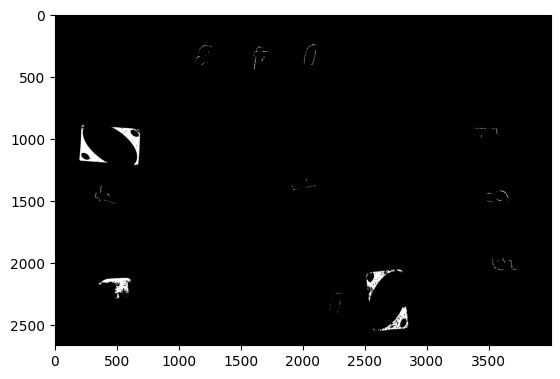

In [348]:
lower_black = np.array([0, 0, 0])
upper_black = np.array([180, 255, 110])
_ , black = helpers.mask(lower_black, upper_black, img_color, n_masks=1, space="hsv")
black=helpers.erode(5, 1, black.astype(np.uint8) * 255)
plt.imshow(black,cmap="gray")

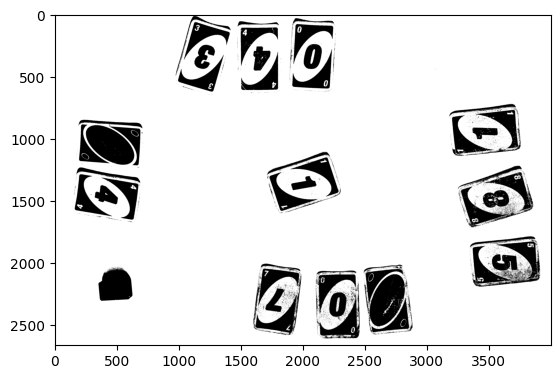

In [349]:
lower_white_1 = np.array([0, 180, 0])
upper_white_1 = np.array([180, 255, 120])

white_masks, white = helpers.mask(lower_white_1, upper_white_1, img_color, n_masks=1, space="hls")
plt.imshow(white,cmap="gray")